In [1]:
import numpy as np
import scipy 
import sys
sys.path.append('/om/user/imgriff/python-packages/chcochleagram')

from src.time_domain_cochleagram import TimeDomainCochleagram
import src.audio_transforms as at
import src.custom_modules as cm
import torch

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

Do quant comparison of the transfer functions between IIR and Truncated FIR  implementations 
- pass lots of white noise through each, average power spectrum and compare
- or could compare impulse responses  from each
- both should give same results 
- express transfer functions in dB 
- look at this for ~5CFs 
- Also do this for rounded exponential filters (Mark's) 

In [3]:
### Setup config args
import yaml

path = 'config/attentional_cue/attn_cue_match_target_speech_distractor_only.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

audio_config = config['data']['audio']


In [4]:
audio_config

{'rep_type': 'cochlea_filt',
 'rep_kwargs': {'sr': 20000,
  'env_sr': 8000,
  'n_channels': 40,
  'low_lim': 40,
  'use_pad': True,
  'rep_on_gpu': False,
  'env_extraction_type': 'Half-wave Rectification',
  'downsampling_type': 'TorchTransformsResample',
  'downsampling_kwargs': {'lowpass_filter_width': 64,
   'rolloff': 0.9475937167399596,
   'resampling_method': 'kaiser_window',
   'beta': 14.769656459379492}},
 'compression_type': 'coch_p3',
 'compression_kwargs': {'scale': 1,
  'offset': 1e-07,
  'clip_value': 5,
  'power': 0.3}}

In [5]:
filter_params = audio_config['rep_kwargs']

filter_params.pop('rep_on_gpu')

False

In [6]:

iir_cochgram =  TimeDomainCochleagram(filter_params=filter_params, downsampling=torch.nn.Identity(), on_gpu=False).compute_rep # use compute rep to get filterbank only 

using IIR cochleagram


In [7]:
iir_cochgram

<function src.time_domain_cochleagram.TimeDomainCochleagram.__init__.<locals>.<lambda>(x)>

In [8]:
audio_config['rep_kwargs']['rep_on_gpu'] = True

from collections import OrderedDict

fir_cochgram = TimeDomainCochleagram(filter_params=filter_params, downsampling=torch.nn.Identity(), on_gpu=True).compute_rep # use compute rep to get filterbank only  

In [9]:
fir_cochgram

ComputeSubbands()

In [10]:
### Generate random noise waves for comparison
import torch
torch.random.manual_seed(1)
sr = audio_config['rep_kwargs']['sr']
noise = torch.randn(100, 2 * sr , dtype=torch.float)

In [11]:
m = torch.nn.Identity()
m(noise)

tensor([[-1.5256, -0.7502, -0.6540,  ...,  2.6504, -1.6963,  1.0666],
        [ 0.2810, -0.0372, -0.5209,  ...,  1.2975,  0.6823,  1.2542],
        [ 2.3565,  1.1686,  1.6322,  ..., -2.1419, -0.4592, -0.0110],
        ...,
        [ 1.4149,  0.9895, -1.4879,  ..., -0.0172, -0.8140, -1.5262],
        [ 0.1829, -0.1122, -0.4800,  ..., -0.6120,  0.8035,  0.8654],
        [-0.1587, -0.5656, -0.8806,  ..., -0.4532,  0.3513,  0.4485]])

In [12]:
iir_noise = torch.stack([iir_cochgram(noise_eg) for noise_eg in noise], dim=0)

In [13]:
iir_noise.shape

torch.Size([100, 40, 40000])

In [14]:
fir_cochgram = fir_cochgram.cuda()

fir_noise = fir_cochgram(noise.cuda()).squeeze().cpu()
# fir_noise = torch.stack([fir_cochgram(noise_eg.cuda, None)[0] for noise_eg in noise.cuda()], dim=0)

In [15]:
torch.abs(fir_noise.mean(0) - iir_noise.mean(0)).mean()

tensor(3.0634e-08)

In [16]:
torch.sqrt(torch.pow(fir_noise.mean(0) - iir_noise.mean(0), 2)).mean()

tensor(3.0634e-08)

Text(0, 0.5, 'Channel')

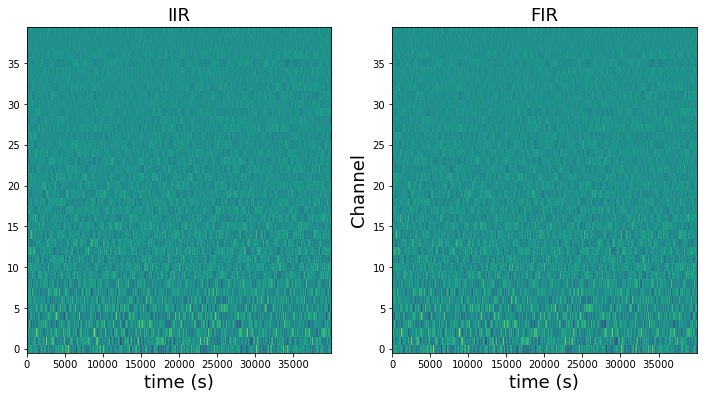

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

iir_av = iir_noise.mean(0)
fir_av = fir_noise.mean(0)



axs[0].imshow(iir_av, aspect='auto', interpolation='None', origin='lower')
axs[1].imshow(fir_av, aspect='auto', interpolation='None', origin='lower')


# axs[0].imshow(iir_av, aspect='auto', interpolation=False, origin='lower')
# axs[1].imshow(fir_av, aspect='auto', interpolation=False, origin='lower')


axs[0].set_title('IIR', fontsize=18)
axs[1].set_title('FIR', fontsize=18)

axs[0].set_xlabel('time (s)', fontsize=18)
axs[1].set_xlabel('time (s)', fontsize=18)

axs[1].set_ylabel('Channel', fontsize=18)


In [18]:
### Get CFs 


def ERB_space(lowFreq=100, highFreq=44100/4, N=100):
    '''
    Python port from Malcom Slaney's Audio Toolbox 
    Port by Ian Griffith. August 24, 2021. 

    This function computes an array of N frequencies uniformly spaced between
    highFreq and lowFreq on an ERB scale.  N is set to 100 if not specified.

    See also linspace, logspace, MakeERBCoeffs, MakeERBFilters.

    For a definition of ERB, see Moore, B. C. J., and Glasberg, B. R. (1983).
    "Suggested formulae for calculating auditory-filter bandwidths and
    excitation patterns," J. Acoust. Soc. Am. 74, 750-753.'''


    # Change the following three parameters if you wish to use a different
    # ERB scale.  Must change in MakeERBCoeffs too.
    EarQ = 9.26449            #  Glasberg and Moore Parameters
    minBW = 24.7
    order = 1
#     print(highFreq)
    # All of the followFreqing expressions are derived in Apple TR #35, "An
    # Efficient Implementation of the Patterson-Holdsworth Cochlear
    # Filter Bank."  See pages 33-34.
    freq_ixs = np.arange(N).reshape(1,-1) + 1 # +1 to match matlab (1:N) construction
    
    cfArray = -(EarQ*minBW) + np.exp(freq_ixs.T * (-np.log(highFreq + EarQ*minBW) + 
            np.log(lowFreq + EarQ*minBW))/ N) * (highFreq + EarQ*minBW)
    return cfArray

center_freqs = np.concatenate(ERB_space(40, 20000/2, 40))

In [19]:
sr

20000

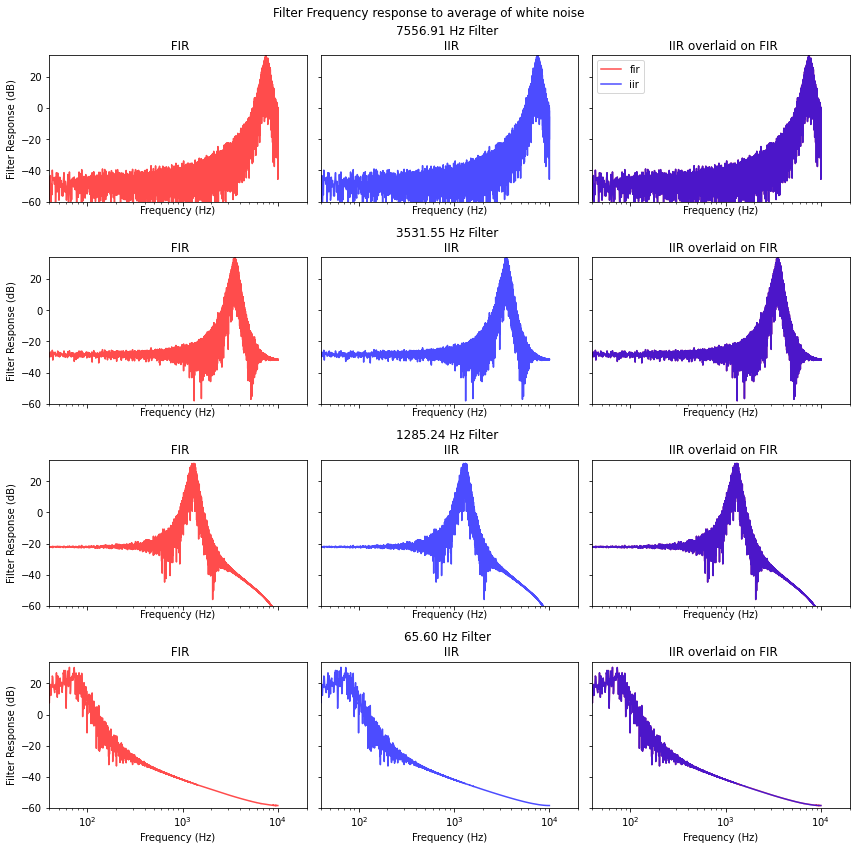

In [20]:
### Look at power spetrum of a few channels:
from scipy.fft import fft

wanted_channels = [2, 10, 20, 38]

sig_len = iir_av.shape[1]
cutoff= sig_len//2

freqScale = np.arange(sig_len)/sig_len*sr 


iir_color = 'b'
fir_color = 'r'

fig, axs = plt.subplots(4,3, figsize=(12,12), sharey=True, sharex=True)
# axs = axs
for ix, channel in enumerate(wanted_channels):
    iir_channel = iir_av[channel, ...].numpy()
    fir_channel = fir_av[channel, ... ].numpy()

    iir_pow_spectrum = 20*(np.log10(abs(fft(iir_channel))))
    fir_pow_spectrum = 20*(np.log10(abs(fft(fir_channel))))

    # Plot individually
    axs[ix,0].semilogx(freqScale[0:cutoff], fir_pow_spectrum.T[0:cutoff], label='fir', color=fir_color, alpha=0.7);
    axs[ix,1].semilogx(freqScale[0:cutoff], iir_pow_spectrum.T[0:cutoff], label='iir', color=iir_color, alpha=0.7);
    # put on same plot
    axs[ix,2].semilogx(freqScale[0:cutoff], fir_pow_spectrum.T[0:cutoff], label='fir', color=fir_color, alpha=0.7);
    axs[ix,2].semilogx(freqScale[0:cutoff], iir_pow_spectrum.T[0:cutoff], label='iir', color=iir_color, alpha=0.7);


    axs[ix,0].axis([40, sr, -60, 34]) # 40 is lowest freq of 40Hz
    axs[ix,1].axis([40, sr, -60, 34]) # 40 is lowest freq of 40Hz
    axs[ix,0].set_xlabel('Frequency (Hz)')
    axs[ix,1].set_xlabel('Frequency (Hz)')
    axs[ix,2].set_xlabel('Frequency (Hz)')

    axs[ix,0].set_ylabel('Filter Response (dB)')
    axs[ix,0].set_title(f' \n FIR')
    axs[ix,1].set_title(f'{center_freqs[channel]:.2f} Hz Filter \n IIR')
    axs[ix,2].set_title(f' \n IIR overlaid on FIR')
fig.suptitle('Filter Frequency response to average of white noise')
# axs[0,0].legend()
axs[0,2].legend()

plt.tight_layout()




### Try with impulse response

In [21]:
ir = torch.hstack([torch.ones(1,1), torch.zeros(1,sr-1)])
print(ir.shape)


torch.Size([1, 20000])


In [22]:
# Pass through systems 
iir_resp = iir_cochgram(ir).squeeze().numpy()
fir_resp = fir_cochgram(ir.cuda()).cpu().squeeze().numpy()

# get fft of each
iir_z = np.abs(fft(iir_resp))
iir_pow = 20 * np.log10(iir_z / iir_z.max())

fir_z = np.abs(fft(fir_resp))
fir_pow = 20 * np.log10(fir_z / iir_z.max())




/tmp/ipykernel_103090/3830716538.py:7: RuntimeWarning: divide by zero encountered in log10
  iir_pow = 20 * np.log10(iir_z / iir_z.max())
/tmp/ipykernel_103090/3830716538.py:10: RuntimeWarning: divide by zero encountered in log10
  fir_pow = 20 * np.log10(fir_z / iir_z.max())


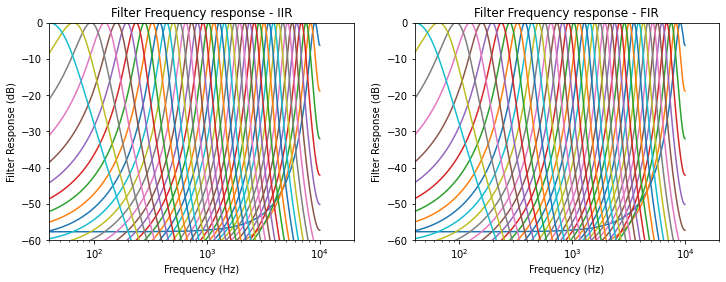

In [23]:
sig_len = len(ir.T)
cutoff= sig_len//2
lowest_frq = 40

freqScale = np.arange(sig_len)/sig_len*sr 

fig, axs = plt.subplots(1,2, figsize=(12,4), sharey=False, sharex=True)
axs = axs.ravel()


for i, ax in enumerate(axs):
    if i == 0:
        ax.semilogx(freqScale[0:cutoff], iir_pow.T[0:cutoff,:]);
        ax.set_title('Filter Frequency response - IIR')
    else:
        ax.semilogx(freqScale[0:cutoff], fir_pow.T[0:cutoff,:]);
        ax.set_title('Filter Frequency response - FIR')

    ax.axis([lowest_frq, sr, -60, 0])
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Filter Response (dB)')


In [24]:
np.mean(np.abs(fir_resp - iir_resp))

0.0

/tmp/ipykernel_103090/1410740354.py:16: RuntimeWarning: divide by zero encountered in log10
  iir_pow = 20 * np.log10(iir_z / iir_z.max())


2000
4000


/tmp/ipykernel_103090/1410740354.py:52: RuntimeWarning: divide by zero encountered in log10
  fir_pow = 20 * np.log10(fir_z)
/tmp/ipykernel_103090/1410740354.py:52: RuntimeWarning: divide by zero encountered in log10
  fir_pow = 20 * np.log10(fir_z)


10000


/tmp/ipykernel_103090/1410740354.py:52: RuntimeWarning: divide by zero encountered in log10
  fir_pow = 20 * np.log10(fir_z)


20000


/tmp/ipykernel_103090/1410740354.py:52: RuntimeWarning: divide by zero encountered in log10
  fir_pow = 20 * np.log10(fir_z)


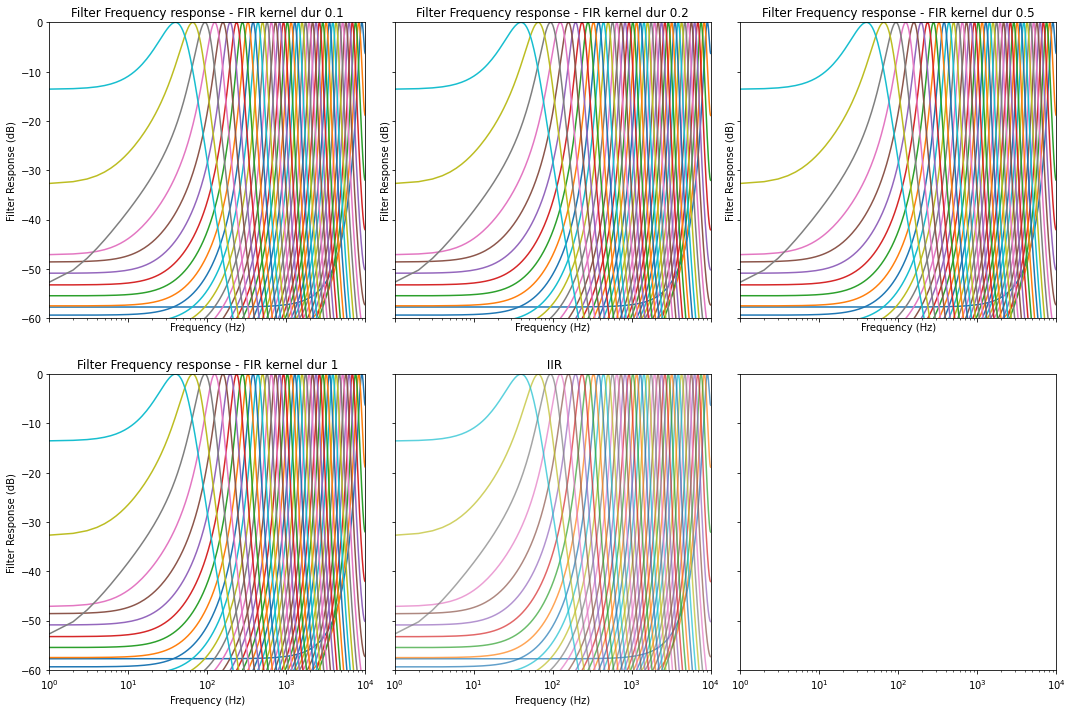

In [29]:
import matplotlib 

fir_cmap = matplotlib.cm.get_cmap('Reds')

fir_kernel_durs = [0.1, 0.2, 0.5, 1] # in seconds


# get impulse 
ir = torch.hstack([torch.ones(1,1), torch.zeros(1,sr-1)])

# Pass through systems 
iir_resp = iir_cochgram(ir).squeeze().numpy()

# get fft of each
iir_z = np.abs(fft(iir_resp))
iir_pow = 20 * np.log10(iir_z / iir_z.max())


sig_len = ir.shape[1]
cutoff= sig_len//2


freqScale = np.arange(sig_len)/sig_len*sr 


iir_color = 'b'
# fir_color = 'r'

channel_z = np.zeros((len(fir_kernel_durs), 40, sr))

fig, axs = plt.subplots(2,3, figsize=(15,10), sharey=True, sharex=True)

axs = axs.ravel()
axs[4].semilogx(freqScale[0:cutoff], iir_pow.T[0:cutoff], label='iir', alpha=0.7);
axs[4].axis([10**0, sr/2, -120, 34]) # 40 is lowest freq of 40Hz
axs[4].set_xlabel('Frequency (Hz)')
axs[4].set_title(f' \n IIR')

ir = ir.cuda()


for k_ix, kernel_dur in enumerate(fir_kernel_durs):
    # get fir with given kerrnel duration 
    fir_op = TimeDomainCochleagram(filter_params=filter_params,
                                    downsampling=torch.nn.Identity(),
                                    on_gpu=True,
                                    impulse_len=kernel_dur).compute_rep.cuda()
    print(fir_op.n_taps)
    fir_resp = fir_op(ir).cpu().squeeze().numpy()

    fir_z = np.abs(fft(fir_resp))
    fir_pow = 20 * np.log10(fir_z)
    channel_z[k_ix,...] = fir_resp


    axs[k_ix].semilogx(freqScale[0:cutoff], fir_pow.T[0:cutoff,:]);
    axs[k_ix].set_title(f'Filter Frequency response - FIR kernel dur {kernel_dur}')
    axs[k_ix].axis([10**0, sr/2, -60, 0])
    axs[k_ix].set_xlabel('Frequency (Hz)')
    axs[k_ix].set_ylabel('Filter Response (dB)')

        
plt.tight_layout()

torch.Size([1, 100000])


/tmp/ipykernel_103090/4134981906.py:17: RuntimeWarning: divide by zero encountered in log10
  iir_pow = 20 * np.log10(iir_z / iir_z.max())


2000
(40, 100000)
4000
(40, 100000)
5000
(40, 100000)
20000
(40, 100000)


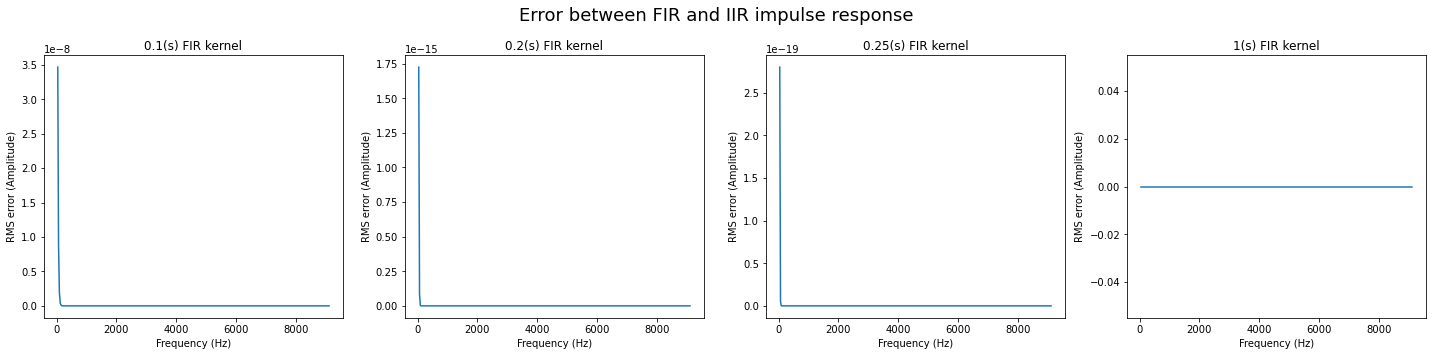

In [46]:
import matplotlib 

fir_cmap = matplotlib.cm.get_cmap('Reds')

fir_kernel_durs = [0.1, 0.2, 0.25, 1] # in seconds


# get impulse 
ir = torch.hstack([torch.ones(1,1), torch.zeros(1,(5*sr)-1)])
print(ir.shape)

# Pass through systems 
iir_resp = iir_cochgram(ir).squeeze().numpy()

# get fft of each
iir_z = np.abs(fft(iir_resp))
iir_pow = 20 * np.log10(iir_z / iir_z.max())


sig_len = ir.shape[1]
cutoff= sig_len//2


freqScale = np.arange(sig_len)/sig_len*sr 


iir_color = 'b'
# fir_color = 'r'

channel_z = np.zeros((len(fir_kernel_durs), 40, sr))

fig, axs = plt.subplots(1,len(fir_kernel_durs), figsize=(20,5), sharey=False, sharex=True)

axs = axs.ravel()
# axs[4].semilogx(freqScale[0:cutoff], iir_pow.T[0:cutoff], label='iir', alpha=0.7);
# axs[4].axis([10**0, sr/2, -120, 34]) # 40 is lowest freq of 40Hz
# axs[4].set_xlabel('Frequency (Hz)')
# axs[4].set_title(f' \n IIR')

ir = ir.cuda()


for k_ix, kernel_dur in enumerate(fir_kernel_durs):
    # get fir with given kerrnel duration 
    fir_op = TimeDomainCochleagram(filter_params=filter_params,
                                    downsampling=torch.nn.Identity(),
                                    on_gpu=True,
                                    impulse_len=kernel_dur).compute_rep.cuda()
    n_taps = fir_op.n_taps
    print(fir_op.n_taps)
    fir_resp = fir_op(ir).cpu().squeeze().numpy()
    print(fir_resp.shape)

    # truncate to compare valid regions of FIR
    error = np.sqrt(np.mean(np.power(fir_resp.T[:n_taps,:] - iir_resp.T[:n_taps,:], 2), axis=0))
    # error = np.sqrt(np.mean(np.power(fir_resp.T - iir_resp.T, 2), axis=0))

    # db_error = 20 * np.log10(error)
    axs[k_ix].plot(center_freqs, error);
    # axs[k_ix].semilogx(center_freqs, db_error);
    # axs[k_ix].axis([20, 5000, -240, 0])


    axs[k_ix].set_title(f'{kernel_dur}(s) FIR kernel')
    # axs[k_ix].xtick_lables(center_freqs)
    axs[k_ix].set_xlabel('Frequency (Hz)')
    axs[k_ix].set_ylabel('RMS error (Amplitude)')

    # axs[k_ix].set_ylabel('Filter Response (dB)')

plt.suptitle('Error between FIR and IIR impulse response', fontsize=18)
plt.tight_layout()

torch.Size([1, 100000])


/tmp/ipykernel_103090/3438747583.py:17: RuntimeWarning: divide by zero encountered in log10
  iir_pow = 20 * np.log10(iir_z / iir_z.max())


2000
4000
5000
20000


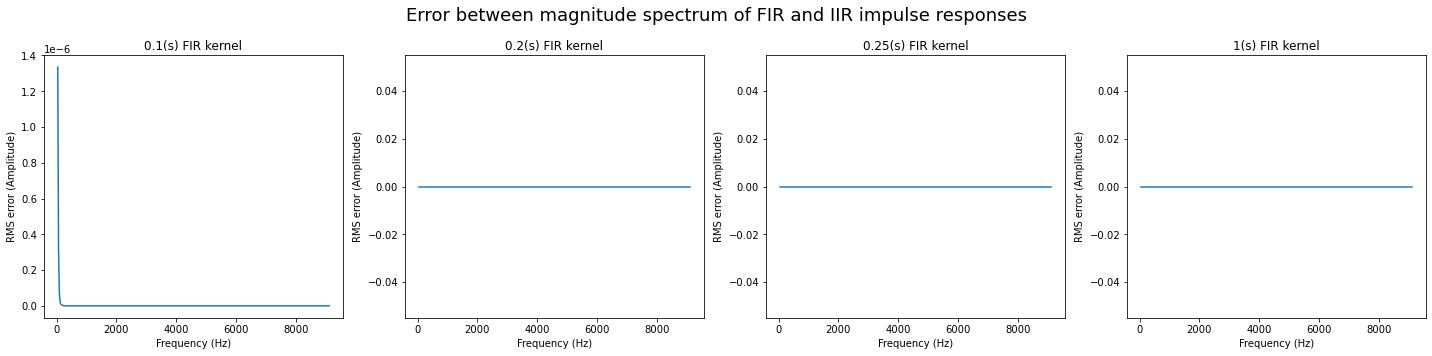

In [45]:
import matplotlib 

fir_cmap = matplotlib.cm.get_cmap('Reds')

fir_kernel_durs = [0.1, 0.2, 0.25, 1] # in seconds


# get impulse 
ir = torch.hstack([torch.ones(1,1), torch.zeros(1,(5*sr)-1)])
print(ir.shape)

# Pass through systems 
iir_resp = iir_cochgram(ir).squeeze().numpy()

# get fft of each
iir_z = np.abs(fft(iir_resp))
iir_pow = 20 * np.log10(iir_z / iir_z.max())


sig_len = ir.shape[1]
cutoff= sig_len//2


freqScale = np.arange(sig_len)/sig_len*sr 


iir_color = 'b'
# fir_color = 'r'

channel_z = np.zeros((len(fir_kernel_durs), 40, sr))

fig, axs = plt.subplots(1,len(fir_kernel_durs), figsize=(20,5), sharey=False, sharex=True)

axs = axs.ravel()
# axs[4].semilogx(freqScale[0:cutoff], iir_pow.T[0:cutoff], label='iir', alpha=0.7);
# axs[4].axis([10**0, sr/2, -120, 34]) # 40 is lowest freq of 40Hz
# axs[4].set_xlabel('Frequency (Hz)')
# axs[4].set_title(f' \n IIR')

ir = ir.cuda()


for k_ix, kernel_dur in enumerate(fir_kernel_durs):
    # get fir with given kerrnel duration 
    fir_op = TimeDomainCochleagram(filter_params=filter_params,
                                    downsampling=torch.nn.Identity(),
                                    on_gpu=True,
                                    impulse_len=kernel_dur).compute_rep.cuda()
    print(fir_op.n_taps)
    fir_resp = fir_op(ir).cpu().squeeze().numpy()
    # print(fir_resp.shape)

    fir_z = np.abs(fft(fir_resp))
    # fir_pow = 20 * np.log10(fir_z)
    # channel_z[k_ix,...] = fir_resp

    error = np.sqrt(np.mean(np.power(fir_z.T[0:cutoff,:] - iir_z.T[0:cutoff,:],2), axis=0))
    # db_error = 20 * np.log10(error)
    axs[k_ix].plot(center_freqs, error);
    # axs[k_ix].semilogx(center_freqs, db_error);
    # axs[k_ix].axis([20, 5000, -240, 0])


    axs[k_ix].set_title(f'{kernel_dur}(s) FIR kernel')
    # axs[k_ix].xtick_lables(center_freqs)
    axs[k_ix].set_xlabel('Frequency (Hz)')
    axs[k_ix].set_ylabel('RMS error (Amplitude)')

    # axs[k_ix].set_ylabel('Filter Response (dB)')

plt.suptitle('Error between magnitude spectrum of FIR and IIR impulse responses', fontsize=18)

plt.tight_layout()